# KenLM: 2-Gram & 3-Gram

## Setup

In [1]:
import kenlm
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import sys

In [2]:
ROOT = Path("..").resolve()

TRAIN_DATA = ROOT / "data" / "train" / "combined_2.cleaned.state3"
KENLM_DIR = ROOT / "models" / "kenlm"
TMP_DIR = f"{KENLM_DIR}/tmp"

TEST_NEWS_DOMAIN = ROOT / "data" / "test" / "news.cleaned.state4"
TEST_LEGAL_DOMAIN = ROOT / "data" / "test" / "legal.cleaned.state4"
TEST_RELIGION_DOMAIN = ROOT / "data" / "test" / "religion.cleaned.state4"

EVAL_SCRIPT = ROOT / "eval_kenlm.py"

sys.path.insert(0, str(ROOT))
import eval_kenlm

## Load Dataset

In [3]:
train_data = f"{TRAIN_DATA}"
df = pd.read_csv(train_data, header=None, names=["text"])
print(df.shape)
df.head()

(63302, 1)


,text
0,ပြင် သစ် နိုင် ငံ ပါ ရီ မြို့ ပါ့ ဒက်စ် ပ ရ င့...
1,အန် ဒ ရီ ယာ မာ စီ သည် အီ တ လီ အ တွက် စမ်း သပ် ...
2,ပ ထ မ တစ် ဝက် ၏ တော် တော် များ များ အ တွက် က စ...
3,ပေါ် တူ ဂီ သည် ဘယ် သော အ ခါ မှ စွ န့် လွှတ် မှ...
4,အီ တ လီ သည် ပ ထ မ ပိုင်း ၌ ၁၆ ၅ ဖြ င့် ဦး ဆောင...


## KenLM Setup: 2-Gram Model

### Constants

In [4]:
arpa_file_2_gram = f"{KENLM_DIR}/kenlm_2gram.arpa"

### Model Training

In [5]:
!cat {TRAIN_DATA} | lmplz -o 2 -S 4G -T {TMP_DIR} --discount_fallback > {arpa_file_2_gram} 2>{arpa_file_2_gram}.error

### ARPA to Binary

This file conversion allows the model to load faster.

In [6]:
!build_binary {arpa_file_2_gram} {arpa_file_2_gram}.binary

Reading /home/lawun330/Desktop/burmese-domain-specific-lm/models/kenlm/kenlm_2gram.arpa
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
SUCCESS


### Model Loading

In [7]:
if Path(f"{arpa_file_2_gram}.binary").stat().st_size == 0:
    print("ERROR: Binary file is empty! Check the error log:")
    print(Path(f"{arpa_file_2_gram}.error").read_text())
else:
    model_kenlm = kenlm.LanguageModel(f"{arpa_file_2_gram}.binary")
    print(f"Successfully loaded {model_kenlm.order}-gram model.")

Successfully loaded 2-gram model.


### Exploring the Model

In [8]:
!head -30 {arpa_file_2_gram}

\data\
ngram 1=9212
ngram 2=194722

\1-grams:
-5.302327	<unk>	0
0	<s>	-1.3956977
-2.5086591	</s>	0
-2.939925	ပြင်	-0.8630731
-2.939925	သစ်	-0.83378804
-2.456517	နိုင်	-1.8622094
-4.096028	ငံ	-1.2201219
-2.31693	ပါ	-1.5311344
-2.8734248	ရီ	-0.78886235
-2.6195316	မြို့	-1.0886048
-3.5365262	ပါ့	-1.2874824
-4.019682	ဒက်စ်	-0.25334772
-2.5430849	ပ	-1.2983987
-2.4402356	ရ	-1.386267
-3.479119	င့်	-1.1881605
-2.842863	စက်	-0.88049406
-2.712372	၌	-0.58559114
-3.611722	၂၀၀၇	-0.9254495
-2.550944	ခု	-1.3740394
-2.5181146	နှစ်	-1.1630003
-2.8956478	ရပ်	-0.9518779
-2.742121	ဘီ	-0.8651305
-3.3043954	ကမ္ဘာ့	-0.67483914
-2.888688	ဖ	-0.9969991
-2.7610004	လား	-1.3677601


In [9]:
!cat {arpa_file_2_gram}.error

=== 1/5 Counting and sorting n-grams ===
File stdin isn't normal.  Using slower read() instead of mmap().  No progress bar.
Unigram tokens 1878654 types 9212
=== 2/5 Calculating and sorting adjusted counts ===
Chain sizes: 1:110544 2:4294856704
Statistics:
1 9212 D1=0.698871 D2=0.934341 D3+=1.36127
2 194722 D1=0.644492 D2=1.0387 D3+=1.43508
Memory estimate for binary LM:
type      kB
probing 3656 assuming -p 1.5
probing 3692 assuming -r models -p 1.5
trie    1285 without quantization
trie     739 assuming -q 8 -b 8 quantization 
trie    1285 assuming -a 22 array pointer compression
trie     739 assuming -a 22 -q 8 -b 8 array pointer compression and quantization
=== 3/5 Calculating and sorting initial probabilities ===
Chain sizes: 1:110544 2:3115552
=== 4/5 Calculating and writing order-interpolated probabilities ===
Chain sizes: 1:110544 2:3115552
=== 5/5 Writing ARPA model ===
Name:lmplz	VmPeak:4342500 kB	VmRSS:9392 kB	RSSMax:1165128 kB	user:0.803592	sys:0.952332	CPU:1.75596	real:1.7

Unlike Sayar's tutorial, fallback discounts were not required, suggesting that the dataset is sufficiently dense and not overly sparse.

### Model Evaluation

In [10]:
# on train data
!python {EVAL_SCRIPT} {arpa_file_2_gram}.binary {TRAIN_DATA} True

Perplexity (PPL): 50.30
Entropy: 3.9181 nats
Bits per character (BPC): 1.4845


In [11]:
!python {EVAL_SCRIPT} {arpa_file_2_gram}.binary {TEST_NEWS_DOMAIN} True

Perplexity (PPL): 148.52
Entropy: 5.0007 nats
Bits per character (BPC): 1.8643


In [12]:
!python {EVAL_SCRIPT} {arpa_file_2_gram}.binary {TEST_LEGAL_DOMAIN} True

Perplexity (PPL): 229.69
Entropy: 5.4367 nats
Bits per character (BPC): 2.0318


In [13]:
!python {EVAL_SCRIPT} {arpa_file_2_gram}.binary {TEST_RELIGION_DOMAIN} True

Perplexity (PPL): 617.73
Entropy: 6.4260 nats
Bits per character (BPC): 2.4095


## KenLM Setup: 3-Gram Model

### Constants

In [14]:
arpa_file_3_gram = f"{KENLM_DIR}/kenlm_3gram.arpa"

### Model Training

- `-o 3` specifies a 3-gram language model.
- `-S 4G` sets the maximum memory usage, allowing KenLM to use up to 4 GB of RAM.
- `-T {tmp_dir}` specifies the temporary directory used for intermediate files during training.
- `--discount_fallback` boolean ensures the program does not crash on small datasets.

The command then:

- saves the trained language model to the specified ARPA file,
- and redirects error messages (stderr) to a separate log file for debugging.

In [15]:
!cat {TRAIN_DATA} | lmplz -o 3 -S 4G -T {TMP_DIR} --discount_fallback > {arpa_file_3_gram} 2>{arpa_file_3_gram}.error

### ARPA to Binary

This file conversion allows the model to load faster.

In [16]:
!build_binary {arpa_file_3_gram} {arpa_file_3_gram}.binary

Reading /home/lawun330/Desktop/burmese-domain-specific-lm/models/kenlm/kenlm_3gram.arpa
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
SUCCESS


### Model Loading

In [17]:
if Path(f"{arpa_file_3_gram}.binary").stat().st_size == 0:
    print("ERROR: Binary file is empty! Check the error log:")
    print(Path(f"{arpa_file_3_gram}.error").read_text())
else:
    model_kenlm = kenlm.LanguageModel(f"{arpa_file_3_gram}.binary")
    print(f"Successfully loaded {model_kenlm.order}-gram model.")

Successfully loaded 3-gram model.


### Exploring the Model

In [18]:
!head -30 {arpa_file_3_gram}

\data\
ngram 1=9212
ngram 2=194722
ngram 3=663922

\1-grams:
-5.302327	<unk>	0
0	<s>	-1.3871441
-2.5086591	</s>	0
-2.939925	ပြင်	-0.4684561
-2.939925	သစ်	-0.47515664
-2.456517	နိုင်	-1.2007431
-4.096028	ငံ	-0.16896166
-2.31693	ပါ	-0.8389095
-2.8734248	ရီ	-0.42149824
-2.6195316	မြို့	-0.84982556
-3.5365262	ပါ့	-0.7743794
-4.019682	ဒက်စ်	-0.21371716
-2.5430849	ပ	-0.6928252
-2.4402356	ရ	-0.80528545
-3.479119	င့်	-0.39393768
-2.842863	စက်	-0.62907076
-2.712372	၌	-0.48751277
-3.611722	၂၀၀၇	-0.50851065
-2.550944	ခု	-0.5624249
-2.5181146	နှစ်	-0.73819745
-2.8956478	ရပ်	-0.5564694
-2.742121	ဘီ	-0.5948546
-3.3043954	ကမ္ဘာ့	-0.5071659
-2.888688	ဖ	-0.6295368


In [19]:
!cat {arpa_file_3_gram}.error

=== 1/5 Counting and sorting n-grams ===
File stdin isn't normal.  Using slower read() instead of mmap().  No progress bar.
Unigram tokens 1878654 types 9212
=== 2/5 Calculating and sorting adjusted counts ===
Chain sizes: 1:110544 2:1493863168 3:2800993536
Statistics:
1 9212 D1=0.698871 D2=0.934341 D3+=1.36127
2 194722 D1=0.695219 D2=1.07155 D3+=1.432
3 663922 D1=0.74051 D2=1.10111 D3+=1.42411
Memory estimate for binary LM:
type       kB
probing 16468 assuming -p 1.5
probing 17645 assuming -r models -p 1.5
trie     6168 without quantization
trie     3190 assuming -q 8 -b 8 quantization 
trie     5900 assuming -a 22 array pointer compression
trie     2921 assuming -a 22 -q 8 -b 8 array pointer compression and quantization
=== 3/5 Calculating and sorting initial probabilities ===
Chain sizes: 1:110544 2:3115552 3:13278440
=== 4/5 Calculating and writing order-interpolated probabilities ===
Chain sizes: 1:110544 2:3115552 3:13278440
=== 5/5 Writing ARPA model ===
Name:lmplz	VmPeak:435069

Unlike Sayar's tutorial, fallback discounts were not required, suggesting that the dataset is sufficiently dense and not overly sparse.

### Model Evaluation

In [20]:
# on train data
!python {EVAL_SCRIPT} {arpa_file_3_gram}.binary {TRAIN_DATA} True

Perplexity (PPL): 13.84
Entropy: 2.6279 nats
Bits per character (BPC): 0.9957


In [21]:
!python {EVAL_SCRIPT} {arpa_file_3_gram}.binary {TEST_NEWS_DOMAIN} True

Perplexity (PPL): 115.34
Entropy: 4.7479 nats
Bits per character (BPC): 1.7700


In [22]:
!python {EVAL_SCRIPT} {arpa_file_3_gram}.binary {TEST_LEGAL_DOMAIN} True

Perplexity (PPL): 187.54
Entropy: 5.2340 nats
Bits per character (BPC): 1.9561


In [23]:
!python {EVAL_SCRIPT} {arpa_file_3_gram}.binary {TEST_RELIGION_DOMAIN} True

Perplexity (PPL): 559.03
Entropy: 6.3262 nats
Bits per character (BPC): 2.3721


## Visualization

In [24]:
CORPORA = [
    ("train", TRAIN_DATA),
    ("news", TEST_NEWS_DOMAIN),
    ("legal", TEST_LEGAL_DOMAIN),
    ("religion", TEST_RELIGION_DOMAIN),
]

In [25]:
MODELS = [
    ("2-gram", f"{arpa_file_2_gram}.binary"),
    ("3-gram", f"{arpa_file_3_gram}.binary"),
]

In [26]:
rows = []
for corpus_name, corpus_path in CORPORA:
    row = {"corpus": corpus_name}
    for tag, model_path in [("2g", f"{arpa_file_2_gram}.binary"), ("3g", f"{arpa_file_3_gram}.binary")]:
        ppl, ent, bpc = eval_kenlm.evaluate(model_path, corpus_path)
        row[f"ppl_{tag}"] = ppl
        row[f"ent_{tag}"] = ent
        row[f"bpc_{tag}"] = bpc
    rows.append(row)

In [27]:
df_eval = pd.DataFrame(rows).set_index("corpus")
df_eval

,ppl_2g,ent_2g,bpc_2g,ppl_3g,ent_3g,bpc_3g
corpus,,,,,,
train,50.303417,3.918073,1.484481,13.844737,2.627905,0.995662
news,148.519610,5.000717,1.864291,115.336455,4.747854,1.770022
legal,229.689236,5.436727,2.031838,187.541371,5.233999,1.956074
religion,617.726124,6.426045,2.409496,559.033929,6.326210,2.372062


In [28]:
x = np.arange(len(df_eval.index))
w = 0.35
metrics = [
    ("ppl", "Perplexity (PPL)", True),   # log scale
    ("ent", "Entropy (nats)", False),
    ("bpc", "Bits per character (BPC)", False),
]

saved: /home/lawun330/Desktop/burmese-domain-specific-lm/img/kenlm_2g_vs_3g_metrics.png


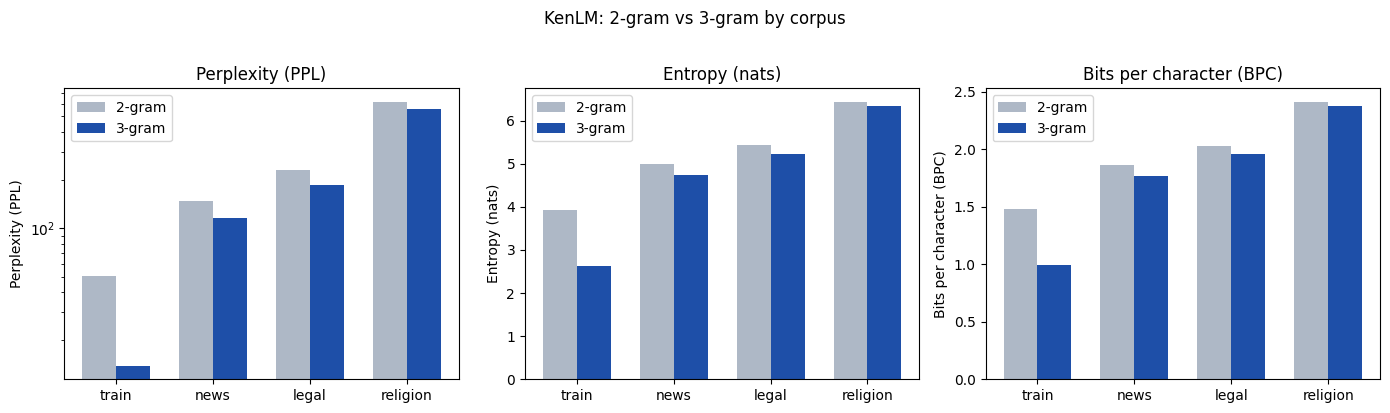

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (prefix, ylabel, use_log) in zip(axes, metrics):
    col_2g = f"{prefix}_2g"
    col_3g = f"{prefix}_3g"
    ax.bar(x - w / 2, df_eval[col_2g], width=w, label="2-gram", color="#AEB8C6")
    ax.bar(x + w / 2, df_eval[col_3g], width=w, label="3-gram", color="#1E4FA8")
    ax.set_xticks(x, df_eval.index)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend()
    if use_log:
        ax.set_yscale("log")

fig.suptitle("KenLM: 2-gram vs 3-gram by corpus", y=1.02)
plt.tight_layout()

out_path = ROOT / "img" / "kenlm_2g_vs_3g_metrics.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print("saved:", out_path)

plt.show()

## Conclusion

### Model-Wise
The 3-gram model consistently performs better because it has:

- lower perplexity
- lower entropy
- lower bits-per-character

across every domain.

This shows that adding one more context token clearly improves predictive power. This also suggests that:

- local word dependencies matter
- the corpus contains useful short-range structures
- the 3-gram model captures phrase patterns that the 2-gram model misses

### Domain-Wise

From easiest to hardest for the model, the domains are:

- news
- legal
- religion

This likely means that:

- news text is closest to the training distribution
- legal text is more formulaic and specialized
- religious text differs the most in vocabulary and writing style